In [1]:
%pip install pandas, scikit-learn, lightgbm, xgboost, catboost, optuna, shap, matplotlib, seabornn,

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: 'pandas,': Expected end or semicolon (after name and no valid version specifier)
    pandas,
          ^


In [2]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
import matplotlib.pyplot as plt
import platform

# 운영체제에 맞춰 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
    
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [214]:
import pandas as pd

# 1. train 데이터 로드
train = pd.read_csv('train.csv')

# 2. 데이터 명세 엑셀 파일 로드 (read_excel 사용)
# 파일명이 정확히 '데이터 명세.xlsx'라고 가정합니다
spec = pd.read_excel('데이터 명세.xlsx')

# 3. 데이터 확인
print("--- Train 데이터 미리보기 ---")
print(train.head())

print("\n--- 데이터 명세 미리보기 ---")
print(spec.head())

--- Train 데이터 미리보기 ---
             ID 시술 시기 코드 시술 당시 나이  임신 시도 또는 마지막 임신 경과 연수 시술 유형 특정 시술 유형  \
0  TRAIN_000000   TRZKPL  만18-34세                    NaN   IVF     ICSI   
1  TRAIN_000001   TRYBLT  만45-50세                    NaN   IVF     ICSI   
2  TRAIN_000002   TRVNRY  만18-34세                    NaN   IVF      IVF   
3  TRAIN_000003   TRJXFG  만35-37세                    NaN   IVF     ICSI   
4  TRAIN_000004   TRVNRY  만18-34세                    NaN   IVF     ICSI   

   배란 자극 여부    배란 유도 유형  단일 배아 이식 여부  착상 전 유전 검사 사용 여부  ...  기증 배아 사용 여부  \
0         1  기록되지 않은 시행          0.0               NaN  ...          0.0   
1         0      알 수 없음          0.0               NaN  ...          0.0   
2         1  기록되지 않은 시행          0.0               NaN  ...          0.0   
3         1  기록되지 않은 시행          0.0               NaN  ...          0.0   
4         1  기록되지 않은 시행          0.0               NaN  ...          0.0   

   대리모 여부  PGD 시술 여부  PGS 시술 여부  난자 채취 경과일  난자 해동 경과일  난자 혼합 경과일  배아 

In [215]:
import numpy as np
import pandas as pd

# 팀의 v2 파생 변수 엔진
def build_v2_gated(df):
    def NUM(df, c): return pd.to_numeric(df[c], errors="coerce") if c in df else pd.Series(0, index=df.index)
    def DIV(num, den): den = den.astype(float); return num.astype(float) / den.where(den > 0)
    
    Mk = {"신선": NUM(df, "신선 배아 사용 여부") == 1, "동결": NUM(df, "동결 배아 사용 여부") == 1,
          "ICSI": NUM(df, "미세주입된 난자 수") > 0, "본인난자": df["난자 출처"].astype(str) == "본인 제공"}
    
    F = {}
    F["g신선_수정률"] = DIV(NUM(df, "총 생성 배아 수"), NUM(df, "혼합된 난자 수")).where(Mk["신선"])
    F["g본인_난자수율"] = DIV(NUM(df, "총 생성 배아 수"), NUM(df, "수집된 신선 난자 수")).where(Mk["본인난자"])
    F["FZ2_해동이식률"] = DIV(NUM(df, "이식된 배아 수"), NUM(df, "해동된 배아 수"))
    return pd.DataFrame(F, index=df.index).fillna(0)

# 팀의 v3 파생 변수 엔진
def build_new_derived(df):
    df_v3 = pd.DataFrame(index=df.index)
    # 기존 코드의 핵심 로직 추출
    tx = pd.to_numeric(df["이식된 배아 수"], errors="coerce").fillna(0)
    sto = pd.to_numeric(df["저장된 배아 수"], errors="coerce").fillna(0)
    ses = (df["단일 배아 이식 여부"] == 1).values if "단일 배아 이식 여부" in df else False
    
    df_v3["EL_set_type"] = np.where(~ses, 0, np.where(sto.values > 0, 2, 1))
    df_v3["FA_no_transfer"] = (tx == 0).astype(int)
    return df_v3

In [216]:
import re
from sklearn.preprocessing import LabelEncoder
import pandas as pd

meta_data = {}
# 타겟 컬럼 이름을 설정하세요 (데이터셋에 맞춰 수정 가능)
TARGET_COL = '임신 성공 여부' 
def bin_age_refined(age_str, col_name):
    if col_name == '시술 당시 나이':
        age_map = {
            '만18-34세': 1, '만35-37세': 2, '만38-39세': 3, 
            '만40-42세': 4, '만43-44세': 5, '만45-50세': 6, '알 수 없음': 3
        }
    else:
        age_map = {
            '만20세 이하': 1, '만21-25세': 2, '만26-30세': 3, 
            '만31-35세': 4, '만36-40세': 5, '만41-45세': 6, '알 수 없음': 3
        }
    return age_map.get(str(age_str), 3)

def preprocess_final(df, is_train=True, train_columns=None):
    df = df.copy()
    
    # [타겟 보호]
    target_data = None
    if TARGET_COL in df.columns:
        target_data = df[TARGET_COL]
        df = df.drop(columns=[TARGET_COL])
    
    # 1. 시도 여부 보정
    flag_cols = ['PGS 시술 여부', 'PGD 시술 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부']
    for col in flag_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0).astype(int)
    
    df.loc[df['착상 전 유전 검사 사용 여부'] == 1, 'PGS 시술 여부'] = 1
    df.loc[df['착상 전 유전 진단 사용 여부'] == 1, 'PGD 시술 여부'] = 1

    # 2. 나이 구획화 (이제 함수가 밖에 있으므로 호출만 하면 됨)
    age_cols = ['시술 당시 나이', '난자 기증자 나이', '정자 기증자 나이']
    for col in age_cols:
        if col in df.columns:
            df[f'{col}_구획'] = df[col].apply(lambda x: bin_age_refined(x, col))
            df = df.drop(columns=[col])

    # 3. 범주형 변수 처리
    categorical_cols = ['시술 유형', '시술 시기 코드', '난자 출처', '정자 출처']
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].fillna('알 수 없음')
            if col == '시술 유형':
                if is_train and target_data is not None:
                    temp_df = df.copy()
                    temp_df[TARGET_COL] = target_data
                    target_map = temp_df.groupby(col)[TARGET_COL].mean().to_dict()
                    meta_data['target_map_시술유형'] = target_map
                    df['시술유형_성공률'] = df[col].map(target_map)
                else:
                    # [여기서 수정!] 테스트 데이터 처리 시 에러 방지
                    target_map = meta_data.get('target_map_시술유형', {})
                    # 학습 데이터의 전체 성공률(Global Mean)을 미리 계산해서 넣어두는 것이 가장 정확합니다.
                    # meta_data에 따로 저장하지 않았다면 기본값 0.5를 사용하세요.
                    global_mean = meta_data.get('global_mean_success', 0.5) 
                    df['시술유형_성공률'] = df[col].map(target_map).fillna(global_mean)
            
            if is_train:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                meta_data[col] = le
            else:
                le = meta_data.get(col)
                df[col] = df[col].apply(lambda x: le.transform([x])[0] if (le and x in le.classes_) else -1)

    # 3. 숫자 컬럼 정제
    count_cols = ['총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', 
                  '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수']
    for col in count_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).apply(lambda x: re.sub(r'[^0-9]', '', x))
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

    # 4. 원-핫 인코딩
    if '배아 생성 주요 이유' in df.columns:
        df = pd.get_dummies(df, columns=['배아 생성 주요 이유'], prefix='이유')

     # preprocess_final 마지막 return 직전에 추가
    v2_features = build_v2_gated(df)
    v3_features = build_new_derived(df)

# 기존 df와 가로로 병합 (axis=1)
    df = pd.concat([df, v2_features, v3_features], axis=1)        

    # [핵심] Train 구조 반영하기
    if not is_train and train_columns is not None:
        for col in train_columns:
            if col not in df.columns:
                df[col] = 0
        df = df[train_columns]
    # --- 기존 전처리 로직 끝 ---

    # [타겟 복구] 전처리 완료 후 타겟 재결합
    if target_data is not None:
        df[TARGET_COL] = target_data

   
    return df

# 1. 원본 데이터 로드
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# 2. Train 전처리
train_df = preprocess_final(train, is_train=True)

# 3. [핵심 수정] 타겟 컬럼을 제외한 피처 컬럼 리스트만 추출
# train_df에서 타겟 컬럼만 뺀 순수 피처 컬럼들로만 test_df의 구조를 맞춥니다.
feature_columns = [col for col in train_df.columns if col != TARGET_COL]

# 4. Test 전처리 (타겟 컬럼이 제거된 피처 리스트만 전달)
test_df = preprocess_final(test, is_train=False, train_columns=feature_columns)

# 이제 test_df에는 타겟 컬럼이 존재하지 않으며, 피처 구조는 train_df와 완벽히 일치합니다.
print(f"Train 컬럼 수 (타겟 포함): {len(train_df.columns)}")
print(f"Test 컬럼 수 (타겟 제외): {len(test_df.columns)}")

Train 컬럼 수 (타겟 포함): 87
Test 컬럼 수 (타겟 제외): 86


In [188]:
import re
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 인코더 저장소
meta_data = {}
TARGET_COL = '임신 성공 여부' # 실제 데이터의 타겟 컬럼명으로 설정

def process_specific_cols(df, is_train=True, train_columns=None):
    df = df.copy()

    # [타겟 보호] 전처리 시작 전 타겟을 잠시 분리
    target_data = None
    if TARGET_COL in df.columns:
        target_data = df[TARGET_COL]
        df = df.drop(columns=[TARGET_COL])

    # 1. 특정 시술 유형 (LabelEncoder 관리)
    if '특정 시술 유형' in df.columns:
        df['특정 시술 유형'] = df['특정 시술 유형'].apply(lambda x: str(x).split('/')[0].strip())
        df['특정 시술 유형'] = df['특정 시술 유형'].replace('Unknown', '알 수 없음')
        
        if is_train:
            le = LabelEncoder()
            df['특정 시술 유형'] = le.fit_transform(df['특정 시술 유형'].astype(str))
            meta_data['le_proc_type'] = le 
        else:
            le = meta_data.get('le_proc_type')
            df['특정 시술 유형'] = df['특정 시술 유형'].apply(lambda x: le.transform([x])[0] if (le and x in le.classes_) else -1)

    # 2. 배란 유도 유형
    if '배란 유도 유형' in df.columns:
        df['배란 유도 유형'] = df['배란 유도 유형'].replace('알 수 없음', '기록되지 않은 시행')
        ovulation_map = {'기록되지 않은 시행': 0, '세트로타이드(억제제)': 1, '생식선 자극호르몬': 2}
        df['배란 유도 유형'] = df['배란 유도 유형'].map(ovulation_map).fillna(0).astype(int)

    # 4. 원-핫 인코딩
    if '배아 생성 주요 이유' in df.columns:
        df = pd.get_dummies(df, columns=['배아 생성 주요 이유'], prefix='이유')

    if 'ID' in df.columns:
        df = df.drop(columns=['ID'])

    # 5. [핵심] Train 데이터 구조 반영 (Test인 경우)
    if not is_train and train_columns is not None:
        for col in train_columns:
            if col not in df.columns:
                df[col] = 0
        df = df[train_columns]    

    # [타겟 복구] 전처리 완료 후 타겟 재결합
    if target_data is not None:
        df[TARGET_COL] = target_data
        
    return df

# 실행
# 먼저 전처리 함수를 통해 데이터 전체를 가공
train_df = process_specific_cols(train_df, is_train=True)
test_df = process_specific_cols(test_df, is_train=False, train_columns=train_df.drop(columns=[TARGET_COL]).columns)
# 이제 test_df에는 타겟 컬럼이 존재하지 않으며, 피처 구조는 train_df와 완벽히 일치합니다.
print(f"Train 컬럼 수 (타겟 포함): {len(train_df.columns)}")
print(f"Test 컬럼 수 (타겟 제외): {len(test_df.columns)}")

Train 컬럼 수 (타겟 포함): 86
Test 컬럼 수 (타겟 제외): 85


In [217]:
def process_pregnancy_history_advanced(df):
    df = df.copy()
    col = '임신 시도 또는 마지막 임신 경과 연수'
    
    # 1. 정보 출처 구분: 단순한 결측 플래그를 넘어 '누락의 이유'를 간접 표현
    # 결측치를 -1로 설정하여 모델이 '데이터 없음'이라는 상태를 독립적인 카테고리로 학습하게 합니다.
    df['is_pregnancy_history_missing'] = df[col].isnull().astype(int)
    
    # 2. 고위험군/저위험군 구분: 중앙값 대신 그룹별 평균 활용
    # 나이가 많을수록 임신 경과 연수가 길어질 가능성이 큼 (나이와 상관관계가 높음)
    # 그래서 나이대별 중앙값으로 채우는 것이 훨씬 정확합니다.
    df[col] = df.groupby('시술 당시 나이_구획')[col].transform(lambda x: x.fillna(x.median()))
    
    # 3. 전체 중앙값으로 보정 (남은 결측치 처리)
    df[col] = df[col].fillna(df[col].median())
    
    return df
train_df = process_pregnancy_history_advanced(train_df)
test_df = process_pregnancy_history_advanced(test_df)

In [218]:
# 1. 학습 데이터에서 median_gap 계산 (기존과 동일)
valid_train = train_df[train_df['난자 혼합 경과일'].notnull()]
base_train = train_df[['난자 채취 경과일', '난자 해동 경과일']].max(axis=1)
median_gap = (valid_train['난자 혼합 경과일'] - base_train[valid_train.index]).median()

# 2. 전처리 함수 수정: 결측 처리가 안 된 부분은 -1로 처리하는 로직 추가
def process_mixing_date_final(df, gap):
    df = df.copy()
    base_date = df[['난자 채취 경과일', '난자 해동 경과일']].max(axis=1)
    
    # 1) 우선 프로세스상 계산 가능한 것은 채움
    df['난자 혼합 경과일'] = df['난자 혼합 경과일'].fillna(base_date + gap)
    
    # 2) 여전히 NaN인 것은 '혼합 과정 없음'으로 간주 (-1 처리)
    df['has_mixing_process'] = df['난자 혼합 경과일'].notnull().astype(int)
    df['난자 혼합 경과일'] = df['난자 혼합 경과일'].fillna(-1)
    
    # 3) 음수 방지 및 마무리
    df['난자 혼합 경과일'] = df['난자 혼합 경과일'].clip(lower=-1)
    
    return df

# 3. 적용
train_df = process_mixing_date_final(train_df, median_gap)
test_df = process_mixing_date_final(test_df, median_gap)

In [220]:
#전처리 2차
def preprocess_embryo_cols(df):
    df = df.copy()
    
    embryo_cols = [
        '동결 배아 사용 여부', 
        '신선 배아 사용 여부', 
        '기증 배아 사용 여부',
        '단일 배아 이식 여부',
        '대리모 여부'
    ]
    
    for col in embryo_cols:
        if col in df.columns:
            # 1. 원래 결측치였던 행을 기억하기 위해 플래그 생성
            df[f'{col}_missing'] = df[col].isnull().astype(int)
            
            # 2. 결측치를 0으로 채우기
            df[col] = df[col].fillna(0).astype(int)

    # [사용자님의 통찰 반영]
    # 난자 해동 경과일이 결측인 경우 -> '난자 채취 경과일' 값을 가져옴 (신선 시술임을 가정)
    # 즉, 해동 과정이 없는 경우 채취 시점이 곧 시작 시점과 같다고 판단
    df['난자 해동 경과일'] = df['난자 해동 경과일'].fillna(df['난자 채취 경과일'])
    
    # 배아 해동 경과일 역시 '배아 이식 경과일'과 연결하여 보정
    df['배아 해동 경과일'] = df['배아 해동 경과일'].fillna(df['배아 이식 경과일'])
    
    # 0으로 남은 부분(채취일조차 없는 경우)은 최종 0으로 처리
    df['난자 해동 경과일'] = df['난자 해동 경과일'].fillna(0)
    df['배아 해동 경과일'] = df['배아 해동 경과일'].fillna(0)
    
    minor_missing_cols = [
    '미세주입된 난자 수', '미세주입 배아 이식 수', '미세주입에서 생성된 배아 수',
    '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동 난자 수', 
    '해동된 배아 수', '저장된 신선 난자 수', '혼합된 난자 수', 
    '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수'
    ]

    for col in minor_missing_cols:
        if col in df.columns:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)


    return df
# 적용
train_df = preprocess_embryo_cols(train_df)
test_df = preprocess_embryo_cols(test_df)

In [221]:
#데이터엔지니어링!!!
def create_and_refine_features(df):
    df = df.copy()
    
    # [핵심 수정] 연산에 필요한 컬럼들을 강제로 숫자형으로 변환
    # 'coerce'를 쓰면 숫자로 바꿀 수 없는 값은 NaN이 되고, 이후 fillna(0)으로 0이 됩니다.
    cols_to_numeric = ['총 생성 배아 수', '수집된 신선 난자 수', '이식된 배아 수', 
                       '총 출산 횟수', '총 임신 횟수', '배아 이식 경과일', '난자 채취 경과일']
    
    for col in cols_to_numeric:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    
    # 이제 안전하게 연산 수행 가능
    df['embryo_efficiency'] = df['총 생성 배아 수'] / (df['수집된 신선 난자 수'] + 1e-9)
    df['implantation_efficiency'] = df['이식된 배아 수'] / (df['총 생성 배아 수'] + 1e-9)
    
    # 여기서 에러가 나던 부분이 해결됩니다.
    df['has_history'] = ((df['총 출산 횟수'] > 0) | (df['총 임신 횟수'] > 0)).astype(int)
    
    cause_cols = [c for c in df.columns if '불임 원인 -' in c]
    df['total_causes_count'] = df[cause_cols].sum(axis=1)
    
    # 배아 이식 경과일이나 난자 채취 경과일 같은 데이터는 
    # 결측치가 많거나 누수 위험이 있다면 신중하게 사용해야 합니다.
    df['time_gap_harvest_to_trans'] = df['배아 이식 경과일'] - df['난자 채취 경과일']
    df['is_elective_SET'] = ((df['이식된 배아 수'] == 1) & (df['시술 당시 나이_구획'] < 35)).astype(int)
    
    # 2. 과적합 방지를 위한 불필요 컬럼 드롭 (제거 리스트)
    # 1) 중요도가 낮거나, 2) ID처럼 정보량이 없는 것, 3) 누수 위험이 큰 것
    drop_cols = [
        'ID', 
        '난자 채취 경과일', # 파생 변수 생성 후 원본 삭제
        '배아 이식 경과일', 
        '총 출산 횟수',     # has_history 생성 후 원본 삭제
        '총 임신 횟수'
    ]
    # 1. 연령 보정
    df['egg_to_age_ratio'] = df['수집된 신선 난자 수'] / (df['시술 당시 나이_구획'] + 1e-9)

    # 3. 경험 지표
    df['history_success_rate'] = df['총 출산 횟수'] / (df['클리닉 내 총 시술 횟수'] + 1e-9)
    
    # 4. 복합 불임 여부
    df['is_complex_cause'] = (df['total_causes_count'] > 1).astype(int)
    # 실제 존재하는 컬럼만 드롭
    existing_drop_cols = [c for c in drop_cols if c in df.columns]
    df = df.drop(columns=existing_drop_cols)
    
    return df

# 적용
train_df = create_and_refine_features(train_df)
test_df = create_and_refine_features(test_df)

In [222]:
import pandas as pd
import numpy as np

def create_advanced_features_v3(df):
    df = df.copy()
    
    # --- [1] 논문 기반 임상 효율성 지표 (상위 변수 강화) ---
    # 배아 선택 효율: 생성된 배아 중 몇 개를 성공적으로 이식했는가
    df['selective_transfer_ratio'] = df['이식된 배아 수'] / (df['총 생성 배아 수'] + 0.1)
    # 복합적 공격성 점수: 치명적 불임 요인에 가중치 부여
    df['aggression_score'] = (df.get('불임 원인 - 난관 질환', 0) * 2.0) + \
                             (df.get('불임 원인 - 자궁내막증', 0) * 1.5)
    
    # --- [2] 시간 및 시술 경험 지표 (비선형성 반영) ---
    df['is_high_frequency_trial'] = (df['총 시술 횟수'] > 3).astype(int)
    df['time_gap_sq'] = df['time_gap_harvest_to_trans'] ** 2 # 시간의 비선형 효과
    
    # --- [3] 결측치 고급 전처리 (임신 기록 변수) ---
    col = '임신 시도 또는 마지막 임신 경과 연수'
    if col in df.columns:
        # 데이터가 없는 것을 하나의 카테고리로 정보화
        df['is_pregnancy_history_missing'] = df[col].isnull().astype(int)
        # 나이 구획별 중앙값으로 채우기 (의학적 상관관계 반영)
        df[col] = df.groupby('시술 당시 나이_구획')[col].transform(lambda x: x.fillna(x.median()))
        # 나머지 결측치는 전체 중앙값으로 마무리
        df[col] = df[col].fillna(df[col].median())
        
    return df

# 적용
train_df = create_advanced_features_v3(train_df)
test_df = create_advanced_features_v3(test_df)

In [223]:
print(train_df.columns.tolist())
print(f"총 피처 개수: {len(train_df.columns)}")

['시술 시기 코드', '임신 시도 또는 마지막 임신 경과 연수', '시술 유형', '특정 시술 유형', '배란 자극 여부', '배란 유도 유형', '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수', '난자 출처', '정자 출처', '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부', '대리모 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 해동 경과일', '난자 혼합 경과일', '배아 해동 경과일', '시술 당시 나이_구획', '난자 기증자 나이_구획', '정자 기증자 나이_구획', '시술유형_성공률', '이유_기증용', '이유_기증용, 난자 저장용', '이유_기증용, 배아 저장용', '이유_기증용, 배아 저장용, 현재 시술용', '이유_기

In [224]:
print(test_df.columns.tolist())
print(f"총 피처 개수: {len(test_df.columns)}") 

['시술 시기 코드', '임신 시도 또는 마지막 임신 경과 연수', '시술 유형', '특정 시술 유형', '배란 자극 여부', '배란 유도 유형', '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수', '난자 출처', '정자 출처', '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부', '대리모 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 해동 경과일', '난자 혼합 경과일', '배아 해동 경과일', '시술 당시 나이_구획', '난자 기증자 나이_구획', '정자 기증자 나이_구획', '시술유형_성공률', '이유_기증용', '이유_기증용, 난자 저장용', '이유_기증용, 배아 저장용', '이유_기증용, 배아 저장용, 현재 시술용', '이유_기

In [225]:
from sklearn.preprocessing import StandardScaler

def apply_final_optimization_v2(df):
    df = df.copy()
    
    # 1. 노이즈 정리 (시술 시기 코드 제거)
    df = df.drop(columns=['시술 시기 코드'], errors='ignore')
    
    # 2. 핵심 변수 강화 (egg_to_age_ratio를 활용한 상호작용)
    # 질문자님이 이미 만드신 변수가 중요하므로, 이를 '시술 당시 나이_구획'과 곱해 비선형성 강화
    df['egg_to_age_interaction'] = df['egg_to_age_ratio'] * df['시술 당시 나이_구획']
    
    # 3. 고위험군 패턴 생성 (결측치 + 불임 원인 가중치)
    # 질문자님 코드에 aggression_score가 있다면 활용하고, 없다면 생략 가능
    if 'aggression_score' in df.columns:
        df['interaction_risk_factor'] = df['is_pregnancy_history_missing'] * df['aggression_score']
    
    # 4. 스케일링 (중요 변수들이 모델에서 공정하게 평가받도록)
    # 질문자님 핵심 변수들을 포함하여 스케일링
    scaler_cols = ['egg_to_age_ratio', 'egg_to_age_interaction']
    if 'aggression_score' in df.columns:
        scaler_cols.append('aggression_score')
        
    scaler = StandardScaler()
    df[scaler_cols] = scaler.fit_transform(df[scaler_cols])
    
    return df
# 적용
train_df = apply_final_optimization_v2(train_df)
test_df = apply_final_optimization_v2(test_df)

print(f"최종 train shape: {train_df.shape}")
print(f"최종 test shape: {test_df.shape}")

최종 train shape: (256351, 103)
최종 test shape: (90067, 102)


In [226]:
# 1. 원본 데이터에서 피처와 타겟 분리
X = train_df.drop(columns=['임신 성공 여부'])
y = train_df['임신 성공 여부']

# 2. 불필요한 열(상수 컬럼) 제거 및 test_df 동기화
# 순서를 보존하면서 유효한 열만 남깁니다.
valid_cols = X.columns[X.nunique() > 1]
X = X[valid_cols]
test_df = test_df[valid_cols]

# 3. 필요하다면 여기서 바로 Train/Val 분할 수행
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"데이터 정제 완료: {X.shape[1]}개의 피처 유지됨.")

데이터 정제 완료: 93개의 피처 유지됨.


In [230]:
import optuna
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd # X_scaled를 생성할 때 pd가 필요합니다

def tune_other_models_v2(model_name, X, y):
    # 1. 수치형 데이터만 선택하여 스케일링 (KNN 에러 방지 핵심)
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns
    scaler = StandardScaler()
    X_scaled = X.copy()
    X_scaled[num_cols] = scaler.fit_transform(X[num_cols])
    
    # 2. 20% 샘플링
    X_sample = X_scaled[num_cols].sample(frac=0.2, random_state=42) # KNN은 반드시 숫자만!
    y_sample = y.loc[X_sample.index]

    def objective(trial):
        if model_name == 'xgb':
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 300, 700),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
                'max_depth': trial.suggest_int('max_depth', 3, 7),
                'subsample': trial.suggest_float('subsample', 0.7, 1.0)
            }
            model = XGBClassifier(**param, random_state=42, n_jobs=-1)
        elif model_name == 'cat':
            param = {
                'iterations': trial.suggest_int('iterations', 300, 700),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
                'depth': trial.suggest_int('depth', 4, 8)
            }
            model = CatBoostClassifier(**param, verbose=0, random_state=42)
        # elif model_name == 'knn':
        #     param = {
        #         'n_neighbors': trial.suggest_int('n_neighbors', 5, 50),
        #         'weights': trial.suggest_categorical('weights', ['uniform', 'distance'])
        #     }
        #     model = KNeighborsClassifier(**param, n_jobs=-1) # 병렬 처리 추가
        
        scores = cross_val_score(model, X_sample, y_sample, cv=3, scoring='roc_auc')
        return scores.mean()

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=15)
    return study.best_params
# 튜닝 실행
best_params_xgb = tune_other_models_v2('xgb', X, y)
best_params_cat = tune_other_models_v2('cat', X, y)
# best_params_knn = tune_other_models_v2('knn', X, y)

[I 2026-06-26 06:27:12,195] A new study created in memory with name: no-name-0cd6c0e0-aaa6-4cec-850a-bdaec16d1c19
[I 2026-06-26 06:27:18,330] Trial 0 finished with value: 0.7238715310994247 and parameters: {'n_estimators': 517, 'learning_rate': 0.047167968957820536, 'max_depth': 6, 'subsample': 0.7903707073999503}. Best is trial 0 with value: 0.7238715310994247.
[I 2026-06-26 06:27:24,433] Trial 1 finished with value: 0.7354873209248222 and parameters: {'n_estimators': 684, 'learning_rate': 0.019854095304407505, 'max_depth': 4, 'subsample': 0.8216419849082551}. Best is trial 1 with value: 0.7354873209248222.
[I 2026-06-26 06:27:27,824] Trial 2 finished with value: 0.7321057245297903 and parameters: {'n_estimators': 304, 'learning_rate': 0.014008993256928419, 'max_depth': 3, 'subsample': 0.8340858779228613}. Best is trial 1 with value: 0.7354873209248222.
[I 2026-06-26 06:27:31,621] Trial 3 finished with value: 0.7354842756693797 and parameters: {'n_estimators': 342, 'learning_rate': 0.

In [253]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifier
from scipy.stats import rankdata
# 베이스 모델 정의
base_models = {
    'xgb': XGBClassifier(**best_params_xgb, random_state=42),
    'cat': CatBoostClassifier(**best_params_cat, verbose=0, random_state=42),
    #'knn': KNeighborsClassifier(**best_params_knn, n_jobs=-1),# 거리 기반 모델
    # 'et': ExtraTreesClassifier(n_estimators=500, random_state=42, n_jobs=-1),
    #'logi': LogisticRegression(solver='liblinear', random_state=42)
}
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    # train과 test의 모든 값을 반영하여 변환
    all_data = pd.concat([X[col], test_df[col]], axis=0).astype(str)
    le.fit(all_data)
    X[col] = le.transform(X[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

# 메타 모델 교체
meta_model = LogisticRegression(solver='liblinear')

train_meta = np.zeros((len(X), len(base_models)))
test_meta = np.zeros((len(test_df), len(base_models)))

# 중요도를 저장할 딕셔너리 (모델별로 저장)
importances_dict = {name: [] for name in base_models.keys()}

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()

# 전체 X에 대해 스케일링 수행
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

# test_df도 동일한 스케일러로 변환
test_scaled = test_df.copy()
test_scaled[num_cols] = scaler.transform(test_df[num_cols])

# K-Fold 학습
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for i, (name, model) in enumerate(base_models.items()):
    print(f"Training Base Model: {name}...")
    
    # 1. 여기서 데이터를 확실하게 넘파이 배열(.values)로 변환합니다.
    # 이렇게 하면 아래의 [train_idx] 인덱싱이 열 이름이 아니라 행 위치로 인식됩니다.
    train_data = (X_scaled if name == 'knn' else X).values
    test_data = (test_scaled if name == 'knn' else test_df).values
    
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(test_df))
    
    model_importances = []
    
    # 2. 이제 train_data는 넘파이 배열이므로 [train_idx] 인덱싱이 정상 작동합니다.
    for train_idx, val_idx in kf.split(train_data):
        X_t, X_v = train_data[train_idx], train_data[val_idx]
        y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_t, y_t)
        if hasattr(model, 'predict_proba'):
            oof_preds[val_idx] = model.predict_proba(X_v)[:, 1]
            test_preds += model.predict_proba(test_data)[:, 1] / kf.get_n_splits()
        else:
            # RidgeClassifier처럼 확률 출력이 없는 모델 대응
            # decision_function은 분류 경계로부터의 거리를 반환
            dist = model.decision_function(X_v)
             # 시그모이드 함수로 0~1 사이 확률로 변환
            oof_preds[val_idx] = 1 / (1 + np.exp(-dist))
    
            # 테스트 데이터 처리
            dist_test = model.decision_function(test_data)
            test_preds += (1 / (1 + np.exp(-dist_test))) / kf.get_n_splits()
        
        if hasattr(model, 'feature_importances_'):
            model_importances.append(model.feature_importances_)
            
    train_meta[:, i] = oof_preds
    test_meta[:, i] = test_preds
    
    # 중요도 저장
    if model_importances:
        importances_dict[name] = np.mean(model_importances, axis=0)
    else:
        importances_dict[name] = np.zeros(train_data.shape[1])

# 2. 여기서 랭크 변환 수행 (학습 루프 밖!)
train_meta_rank = np.zeros_like(train_meta)
test_meta_rank = np.zeros_like(test_meta)

for i in range(train_meta.shape[1]):
    # 랭크를 매긴 뒤, 데이터 개수로 나누어 0~1 사이로 정규화 (Min-Max Scaling)
    train_meta_rank[:, i] = rankdata(train_meta[:, i]) / len(train_meta)
    test_meta_rank[:, i] = rankdata(test_meta[:, i]) / len(test_meta)

# 3. 힐클라이밍 함수 정의
def hill_climbing(train_meta_rank, y, test_meta_rank, iterations=2000, step=0.0001):
    n_models = train_meta_rank.shape[1]
    # 가중치 초기화: [0.33, 0.33, 0.33]으로 시작
    weights = np.ones(n_models) / n_models
    best_auc = roc_auc_score(y, np.dot(train_meta_rank, weights))
    
    for _ in range(iterations):
        for i in range(n_models):
            trial_weights = weights.copy()
            trial_weights[i] += step 
            trial_weights /= trial_weights.sum() # 합계 1 유지
            
            trial_auc = roc_auc_score(y, np.dot(train_meta_rank, trial_weights))
            if trial_auc > best_auc:
                best_auc = trial_auc
                weights = trial_weights
    return weights, best_auc

# 4. 힐클라이밍으로 가중치 최적화 (여기서 로지스틱 회귀를 완전히 대체)
weights, final_auc = hill_climbing(train_meta_rank, y, test_meta_rank)

print(f"\n최종 힐클라이밍 최적화 AUC: {final_auc:.5f}")
print(f"최적 가중치 (XGB, Cat): {weights}")

# 5. 최종 예측값 생성
final_preds = np.dot(test_meta_rank, weights)

Training Base Model: xgb...
Training Base Model: cat...

최종 힐클라이밍 최적화 AUC: 0.73831
최적 가중치 (XGB, Cat): [0.50009999 0.49990001]


In [254]:
import pandas as pd

# 3. 제출 파일 생성
submission = pd.read_csv("sample_submission.csv")

# 4. 결과 저장
# sample_submission의 두 번째 컬럼(보통 probability 또는 target)에 최종 예측값 대입
submission.iloc[:, 1] = final_preds

# 5. 최종 파일 저장
submission.to_csv('final_stacking_submission.csv', index=False)

print("\n스태킹 기반의 최종 제출 파일(final_stacking_submission.csv)이 생성되었습니다.")


스태킹 기반의 최종 제출 파일(final_stacking_submission.csv)이 생성되었습니다.



[상위 20개 중요 피처]
                      Feature       XGB        Cat      Total
77             FA_no_transfer  0.000000  21.847183  21.847183
35                   이식된 배아 수  0.094191  13.056032  13.150222
80    implantation_efficiency  0.294210  11.737332  12.031542
88   selective_transfer_ratio  0.018755  11.739091  11.757846
37                   저장된 배아 수  0.105740   7.640267   7.746007
57                시술 당시 나이_구획  0.029529   4.038436   4.067965
85           egg_to_age_ratio  0.018450   2.938888   2.957338
83  time_gap_harvest_to_trans  0.058336   2.716578   2.774914
91                time_gap_sq  0.000000   2.772153   2.772153
92     egg_to_age_interaction  0.003190   2.623672   2.626862
56                  배아 해동 경과일  0.010285   2.118235   2.128519
32                  총 생성 배아 수  0.037041   2.024545   2.061586
47                      정자 출처  0.008110   2.002005   2.010115
43                   혼합된 난자 수  0.004052   1.675259   1.679312
41                수집된 신선 난자 수  0.022616   1.617413   1

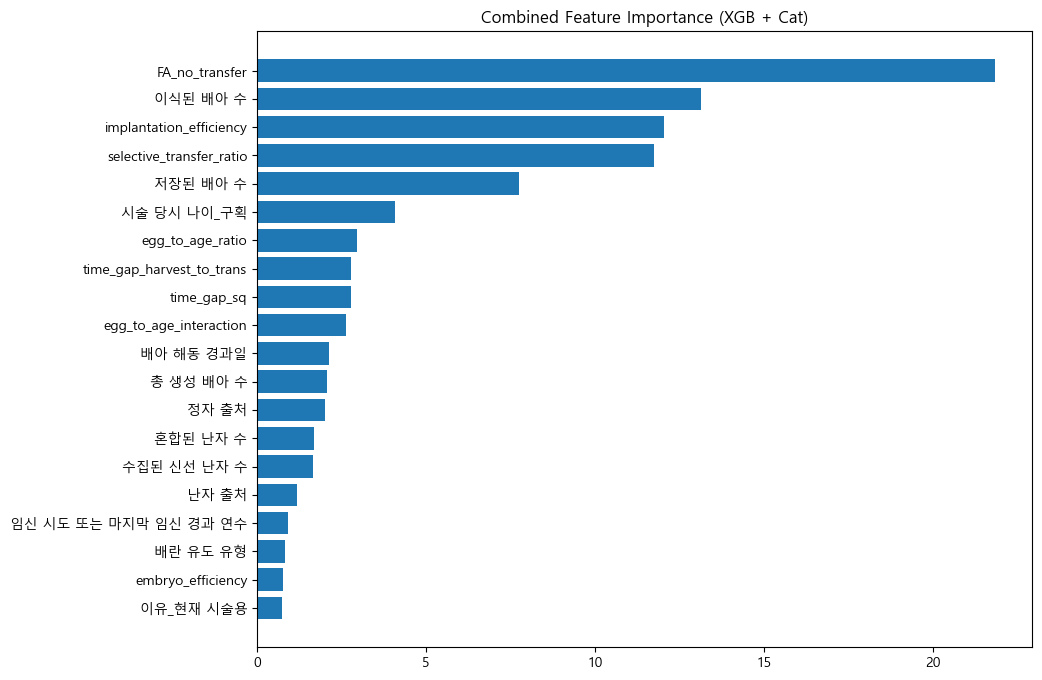

In [235]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 모델별 중요도 데이터프레임 생성
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'XGB': importances_dict['xgb'],
    'Cat': importances_dict['cat']
})

# 2. 중요도 합산 (두 모델의 기여도를 합쳐서 전체 순위 매기기)
importance_df['Total'] = importance_df['XGB'] + importance_df['Cat']
importance_df = importance_df.sort_values(by='Total', ascending=False)

# 3. 결과 출력
print("\n[상위 20개 중요 피처]")
print(importance_df.head(20))

# 4. 시각화 (중요도 분포 확인)
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'].head(20), importance_df['Total'].head(20))
plt.gca().invert_yaxis()
plt.title('Combined Feature Importance (XGB + Cat)')
plt.show()

In [164]:
null_info = pd.DataFrame({
    'Missing_Count': train_df.isnull().sum(),
    'Missing_Ratio': train_df.isnull().mean() * 100
})

# 결측치가 있는 컬럼만 내림차순 정렬
null_info = null_info[null_info['Missing_Count'] > 0].sort_values(by='Missing_Ratio', ascending=False)

print(null_info)

Empty DataFrame
Columns: [Missing_Count, Missing_Ratio]
Index: []
